# QUESTÃO 7: Modelo Baseline de Previsão

## Seção 0: Imports e Configuração

In [1]:
"""
Imports e Configuração do Notebook
==================================
Carrega dependências para análise e modelagem.
"""

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Configuração de diretórios (ROBUSTO para Jupyter)
notebook_dir = Path.cwd()
ROOT_DIR = None

# Procurar "Desafio-Lighthouse-Dados-AI" na hierarquia
for possible_root in [notebook_dir] + list(notebook_dir.parents):
    if possible_root.name == "Desafio-Lighthouse-Dados-AI":
        ROOT_DIR = possible_root
        break

# Fallback: se não encontrou, assumir 2 níveis acima
if ROOT_DIR is None:
    ROOT_DIR = notebook_dir.parent

SRC_DIR = ROOT_DIR / "src"
DATA_PROCESSED = ROOT_DIR / "data" / "processed"

print(f"📁 Diretório: {ROOT_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Importações
print("⏳ Carregando bibliotecas...", end=" ")
import pandas as pd
import numpy as np
print("pandas✓ numpy✓", end=" ")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("sklearn✓")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print("⏳ Carregando módulos personalizados...", end=" ")
try:
    from data.load_data import load_vendas, load_produtos
    from features.feature_engineering import adicionar_colunas_tempo
    from models.forecasting import filtrar_produto, baseline_media_movel_7_dias, treinar_e_prever_baseline
    from utils import salvar_csv, garantir_pasta
    print("✓")
    print("✓ Todos os módulos carregados com sucesso!")
except ImportError as e:
    print(f"\n✗ Erro ao importar módulos: {e}")
    raise

📁 Diretório: c:\Projetos\Desafio-Lighthouse-Dados-AI
⏳ Carregando bibliotecas... pandas✓ numpy✓ sklearn✓
⏳ Carregando módulos personalizados... ✓
✓ Todos os módulos carregados com sucesso!


## Seção 1: Carregamento e Preparação

In [2]:
"""
Carregamento de Dados
====================
"""

print("Carregando dados...\n")

# Carregar dados
df_vendas = load_vendas()
df_produtos = load_produtos()

# Padronizar nomes de colunas
if 'sale_date' in df_vendas.columns:
    df_vendas = df_vendas.rename(columns={'sale_date': 'data'})

# Adicionar features temporais
df_vendas = adicionar_colunas_tempo(df_vendas)

print(f"✓ Vendas: {df_vendas.shape[0]} registros")
print(f"✓ Produtos: {df_produtos.shape[0]} produtos")

# Lista de produtos
print(f"\nProdutos disponíveis: {df_produtos.shape[0]}")
print(f"Colunas de produtos: {list(df_produtos.columns)}")
print(f"\nExemplos de produtos:")

# Exibir colunas disponíveis
cols_display = ['code' if 'code' in df_produtos.columns else 'id',
                'name' if 'name' in df_produtos.columns else 'nome',
                'actual_category' if 'actual_category' in df_produtos.columns else 'categoria',
                'price' if 'price' in df_produtos.columns else 'preco']
cols_display = [c for c in cols_display if c in df_produtos.columns]

display(df_produtos[cols_display].head(10))

Carregando dados...

Colunas encontradas em vendas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']
Coluna de data detectada: 'sale_date'
Coluna de total detectada: 'total'
Shape final de vendas: (9895, 6)
Colunas encontradas em produtos: ['name', 'price', 'code', 'actual_category']
Shape de produtos: (157, 4)
✓ Vendas: 9895 registros
✓ Produtos: 157 produtos

Produtos disponíveis: 157
Colunas de produtos: ['name', 'price', 'code', 'actual_category']

Exemplos de produtos:


,code,name,actual_category,price
0,1,Transponder AIS Maré Magnum,ELETRONICOS,R$ 33122.52
1,2,Transponder Furuno Marlin,ELETRONICOS,R$ 13998.15
2,3,Radar Furuno Pulse Leviathan,E L E T R Ô N I C O S,R$ 9024.19
3,4,Rádio AIS Hydro Tidal Zen,Eletrunicos,R$ 3381.88
4,5,Piloto Automático Furuno Storm,Eletronicoz,R$ 23669.01
5,6,Transponder AIS Vector,Eletrunicos,R$ 11820.21
6,7,Radar AIS Zen,eLeTrÔnIcOs,R$ 19518.77
7,8,GPS AIS Zen,E L E T R Ô N I C O S,R$ 4984.15
8,9,Transponder AIS Titan Pulse,Eletronicoz,R$ 39705.5
9,10,Piloto Automático Simrad Titan Flux Magnum,eletrônicos,R$ 32033.04


---

# QUESTÃO 7 - MODELO BASELINE DE PREVISÃO

## Objetivo
- Selecionar produto: "Motor de Popa Yamaha Evo Dash 155HP"
- Implementar modelo baseline (Média Móvel 7 dias)
- Calcular métricas (MAE, RMSE, R²)
- Gerar previsões e visualizações

## Seleção de Produto

In [3]:
"""
Questão 7: Modelo Baseline de Previsão
======================================
"""

print("="*60)
print("QUESTÃO 7 - MODELO BASELINE DE PREVISÃO")
print("="*60 + "\n")

# Produto alvo
PRODUTO_ALVO = "Motor de Popa Yamaha Evo Dash 155HP"

# Buscar produto - testar diferentes colunas de nome
nome_col = 'name' if 'name' in df_produtos.columns else 'nome'

try:
    produto_info = df_produtos[df_produtos[nome_col].str.contains('Yamaha', case=False, na=False)]
    if len(produto_info) == 0:
        # Se não encontrar com Yamaha, usar primeiro produto com 155
        produto_info = df_produtos[df_produtos[nome_col].str.contains('155', case=False, na=False)]
    
    if len(produto_info) > 0:
        id_produto = produto_info.index[0]
        print(f"✓ Produto selecionado:")
        print(f"  ID: {id_produto}")
        print(f"  Nome: {produto_info[nome_col].values[0]}")
        
        # Detectar nome da coluna de categoria
        cat_col = 'actual_category' if 'actual_category' in df_produtos.columns else 'categoria'
        if cat_col in produto_info.columns:
            print(f"  Categoria: {produto_info[cat_col].values[0]}")
        
        # Detectar nome da coluna de preço
        price_col = 'price' if 'price' in df_produtos.columns else 'preco'
        if price_col in produto_info.columns:
            preco = produto_info[price_col].values[0]
            # Se for string com R$, exibir como está; senão formatar
            if isinstance(preco, str):
                print(f"  Preço: {preco}")
            else:
                print(f"  Preço: R$ {preco:,.2f}")
        print()
    else:
        # Usar primeiro produto como fallback
        id_produto = df_produtos.index[0]
        print(f"⚠️  Produto específico não encontrado. Usando: {df_produtos.loc[id_produto, nome_col]}\n")
        
except Exception as e:
    print(f"✗ Erro ao selecionar produto: {e}")
    # Usar primeiro produto
    id_produto = df_produtos.index[0]
    print(f"Usando produto alternativo: {df_produtos.loc[id_produto, nome_col]}\n")

QUESTÃO 7 - MODELO BASELINE DE PREVISÃO

✓ Produto selecionado:
  ID: 54
  Nome: Motor de Popa Yamaha Evo Dash 155HP
  Categoria: Propulssão
  Preço: R$ 121534.82



In [4]:
"""
Preparação dos Dados para Previsão
===================================
"""

# Filtrar vendas do produto (detectar nomes de colunas)
col_product = 'id_product' if 'id_product' in df_vendas.columns else 'produto'
col_date = 'sale_date' if 'sale_date' in df_vendas.columns else 'data'
col_total = 'total' if 'total' in df_vendas.columns else 'qtd_vendida'

# Filtrar o produto e converter data para datetime
df_produto = df_vendas[df_vendas[col_product] == id_produto].copy()
df_produto[col_date] = pd.to_datetime(df_produto[col_date])

print(f"\nVendas do produto: {df_produto.shape[0]} registros")
print(f"Período: {df_produto[col_date].min().date()} a {df_produto[col_date].max().date()}")

# Agrupamento diário
vendas_diarias = df_produto.groupby(col_date)[col_total].sum().reset_index()
vendas_diarias.columns = ['data', 'vendas']
vendas_diarias = vendas_diarias.sort_values('data').reset_index(drop=True)

print(f"\nVendas diárias: {len(vendas_diarias)} dias com registro")
print(f"Vendas totais: R$ {vendas_diarias['vendas'].sum():,.2f}")
print(f"Vendas médias diárias: R$ {vendas_diarias['vendas'].mean():,.2f}")

# Série completa (incluindo dias sem venda)
data_range = pd.date_range(start=vendas_diarias['data'].min(), end=vendas_diarias['data'].max(), freq='D')
vendas_completo = pd.DataFrame({'data': data_range})
vendas_completo = vendas_completo.merge(vendas_diarias, on='data', how='left')
vendas_completo['vendas'] = vendas_completo['vendas'].fillna(0)

print(f"\nSérie completa (com dias sem venda): {len(vendas_completo)} dias\n")
print("Últimas 10 vendas diárias:")
display(vendas_completo.tail(10))


Vendas do produto: 62 registros
Período: 2023-01-10 a 2024-11-27

Vendas diárias: 58 dias com registro
Vendas totais: R$ 65,859,716.10
Vendas médias diárias: R$ 1,135,512.35

Série completa (com dias sem venda): 688 dias

Últimas 10 vendas diárias:


,data,vendas
678,2024-11-18,0.00
679,2024-11-19,0.00
680,2024-11-20,0.00
681,2024-11-21,0.00
682,2024-11-22,0.00
683,2024-11-23,0.00
684,2024-11-24,1926326.80
685,2024-11-25,0.00
686,2024-11-26,0.00
687,2024-11-27,2728456.85


## Modelo Baseline: Média Móvel 7 Dias

In [6]:
"""
Implementação do Modelo Baseline
===============================
"""

# Calcular média móvel 7 dias
vendas_completo['ma7'] = vendas_completo['vendas'].rolling(window=7, min_periods=1).mean()
vendas_completo['ma7_lag1'] = vendas_completo['ma7'].shift(1)

# Divisão treino/teste (80/20)
split_idx = int(len(vendas_completo) * 0.8)
treino = vendas_completo[:split_idx].copy()
teste = vendas_completo[split_idx:].copy()

# Previsões (usar MA7 anterior como previsão para o dia)
teste['predicao'] = teste['ma7'].shift(1).fillna(treino['ma7'].mean())

print(f"DADOS DE TREINO/TESTE:")
print(f"  Treino: {len(treino)} registros ({split_idx / len(vendas_completo) * 100:.0f}%)")
print(f"  Teste: {len(teste)} registros ({(len(teste) / len(vendas_completo) * 100):.0f}%)\n")

# Calcular métricas
y_real = teste['vendas'].values
y_pred = teste['predicao'].values

mae = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
r2 = r2_score(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / (y_real + 1))) * 100  # Evitar divisão por zero

print(f"MÉTRICAS DO MODELO:")
print(f"  MAE (Erro Absoluto Médio): R$ {mae:,.2f}")
print(f"  RMSE (Raiz do Erro Quadrado): R$ {rmse:,.2f}")
print(f"  MAPE (Erro Percentual): {mape:.2f}%")
print(f"  R² Score: {r2:.4f}")

# Interpretação
print(f"\nINTERPRETAÇÃO:")
if r2 > 0.5:
    print(f" Modelo com bom desempenho (R² = {r2:.2%})")
elif r2 > 0:
    print(f" Modelo com desempenho moderado (R² = {r2:.2%})")
else:
    print(f" Modelo com desempenho ruim (R² = {r2:.2%})")

DADOS DE TREINO/TESTE:
  Treino: 550 registros (80%)
  Teste: 138 registros (20%)

MÉTRICAS DO MODELO:
  MAE (Erro Absoluto Médio): R$ 230,024.99
  RMSE (Raiz do Erro Quadrado): R$ 477,932.82
  MAPE (Erro Percentual): 10144477.42%
  R² Score: -0.0633

INTERPRETAÇÃO:
 Modelo com desempenho ruim (R² = -6.33%)


In [7]:
"""
Análise de Resíduos
==================
"""

# Calcular resíduos
teste['residuo'] = teste['vendas'] - teste['predicao']
teste['erro_pct'] = np.abs(teste['residuo']) / (teste['vendas'] + 1) * 100

print(f"\nANÁLISE DE RESÍDUOS:")
print(f"  Resíduo Médio: R$ {teste['residuo'].mean():,.2f}")
print(f"  Desvio Padrão: R$ {teste['residuo'].std():,.2f}")
print(f"  Mínimo: R$ {teste['residuo'].min():,.2f}")
print(f"  Máximo: R$ {teste['residuo'].max():,.2f}")

# Acurácia (dentro de 20%)
acertos = (teste['erro_pct'] < 20).sum()
acuracia = (acertos / len(teste)) * 100
print(f"\nAcurácia (erro < 20%): {acuracia:.1f}%")

print(f"\nÚltimas 10 previsões:")
display(teste[['data', 'vendas', 'predicao', 'residuo', 'erro_pct']].tail(10))


ANÁLISE DE RESÍDUOS:
  Resíduo Médio: R$ 27,135.63
  Desvio Padrão: R$ 478,900.15
  Mínimo: R$ -535,621.26
  Máximo: R$ 2,453,267.31

Acurácia (erro < 20%): 47.8%

Últimas 10 previsões:


,data,vendas,predicao,residuo,erro_pct
678,2024-11-18,0.00,0.00,0.00,0.00
679,2024-11-19,0.00,0.00,0.00,0.00
680,2024-11-20,0.00,0.00,0.00,0.00
681,2024-11-21,0.00,0.00,0.00,0.00
682,2024-11-22,0.00,0.00,0.00,0.00
683,2024-11-23,0.00,0.00,0.00,0.00
684,2024-11-24,1926326.80,0.00,1926326.80,100.00
685,2024-11-25,0.00,275189.54,-275189.54,27518954.29
686,2024-11-26,0.00,275189.54,-275189.54,27518954.29
687,2024-11-27,2728456.85,275189.54,2453267.31,89.91


## Visualizações do Modelo

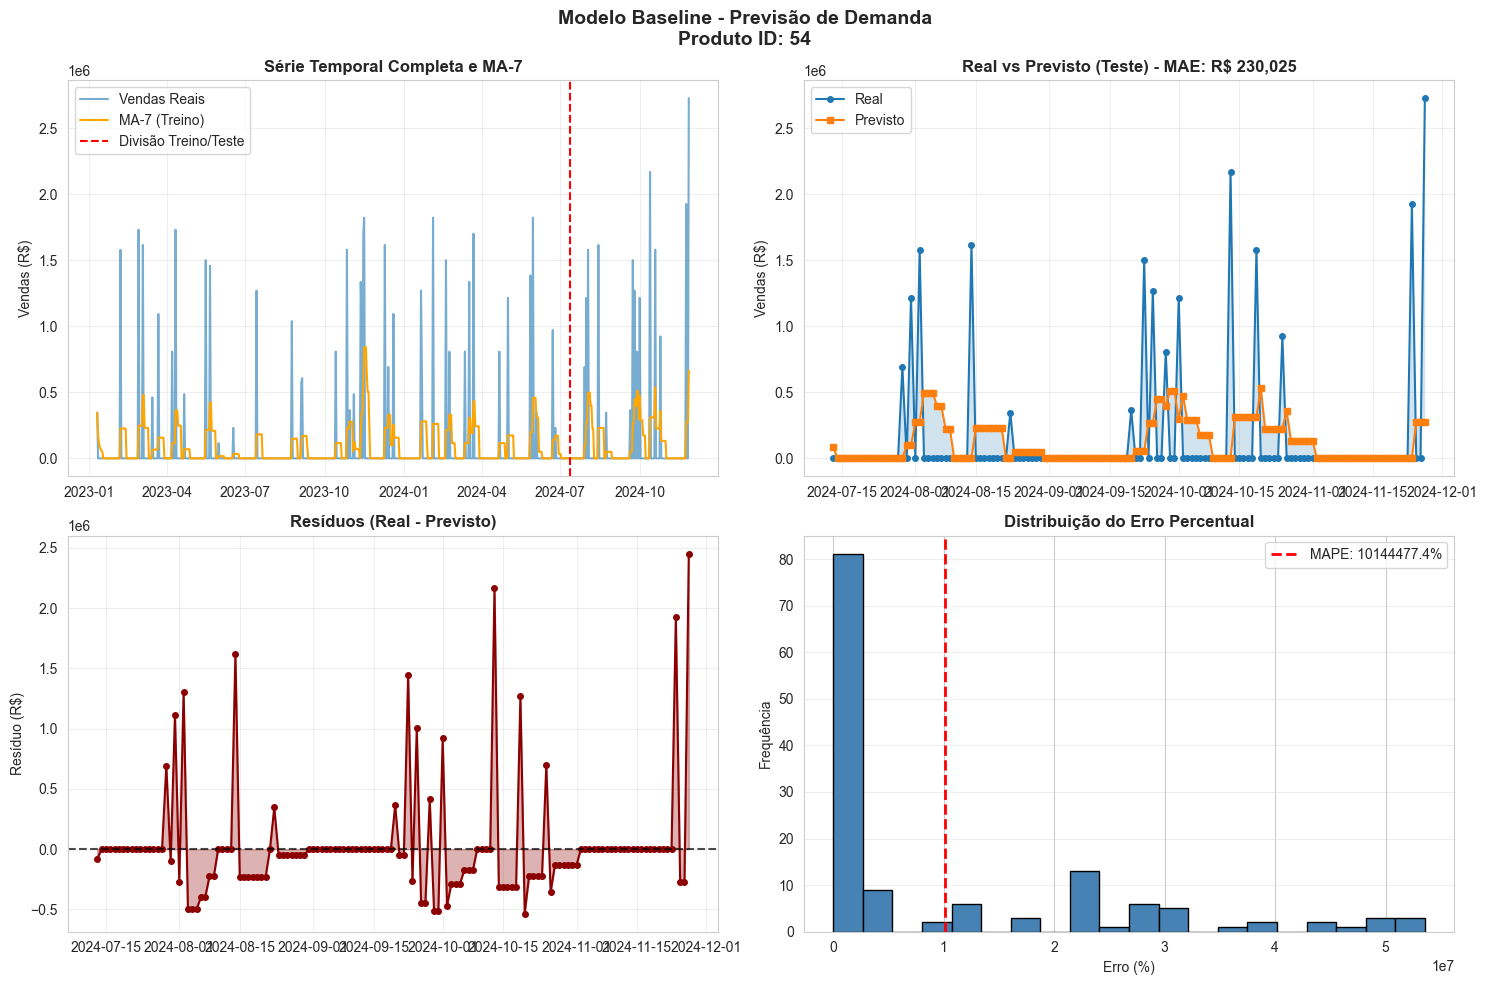


✓ Visualizações exibidas com sucesso


In [8]:
"""
Visualizações: Modelo Baseline
============================
"""

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Modelo Baseline - Previsão de Demanda\nProduto ID: {id_produto}', 
             fontsize=14, fontweight='bold')

# Gráfico 1: Série completa com média móvel
axes[0, 0].plot(vendas_completo['data'], vendas_completo['vendas'], label='Vendas Reais', alpha=0.6)
axes[0, 0].plot(vendas_completo['data'], vendas_completo['ma7'], label='MA-7 (Treino)', color='orange')
axes[0, 0].axvline(x=treino['data'].max(), color='red', linestyle='--', label='Divisão Treino/Teste')
axes[0, 0].set_title('Série Temporal Completa e MA-7', fontweight='bold')
axes[0, 0].set_ylabel('Vendas (R$)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Real vs Predito (Teste)
axes[0, 1].plot(teste['data'], teste['vendas'], label='Real', marker='o', markersize=4)
axes[0, 1].plot(teste['data'], teste['predicao'], label='Previsto', marker='s', markersize=4)
axes[0, 1].fill_between(teste['data'], teste['vendas'], teste['predicao'], alpha=0.2)
axes[0, 1].set_title(f'Real vs Previsto (Teste) - MAE: R$ {mae:,.0f}', fontweight='bold')
axes[0, 1].set_ylabel('Vendas (R$)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Resíduos
axes[1, 0].plot(teste['data'], teste['residuo'], marker='o', markersize=4, color='darkred')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.7)
axes[1, 0].fill_between(teste['data'], teste['residuo'], 0, alpha=0.3, color='darkred')
axes[1, 0].set_title('Resíduos (Real - Previsto)', fontweight='bold')
axes[1, 0].set_ylabel('Resíduo (R$)')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Distribuição de Erros
axes[1, 1].hist(teste['erro_pct'], bins=20, color='steelblue', edgecolor='black')
axes[1, 1].axvline(x=mape, color='red', linestyle='--', linewidth=2, label=f'MAPE: {mape:.1f}%')
axes[1, 1].set_title('Distribuição do Erro Percentual', fontweight='bold')
axes[1, 1].set_xlabel('Erro (%)')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualizações exibidas com sucesso")

## Previsões Futuras

In [9]:
"""
Geração de Previsões Futuras
============================
Utiliza o modelo treinado para fazer previsões dos próximos 30 dias.
"""

# Últimas 7 dias para calcular MA
ultimos_dias = vendas_completo.tail(7)['vendas'].mean()

# Gerar 30 dias futuros
ultima_data = vendas_completo['data'].max()
proximos_30_dias = pd.date_range(start=ultima_data + pd.Timedelta(days=1), periods=30, freq='D')

previsoes_futuras = pd.DataFrame({
    'data': proximos_30_dias,
    'predicao': ultimos_dias  # Usar média dos últimos 7 dias como previsão constante
})

# Adicionar variação (intervalo de confiança)
desvio = vendas_completo['vendas'].std()
previsoes_futuras['limite_inferior'] = previsoes_futuras['predicao'] - 1.96 * desvio
previsoes_futuras['limite_superior'] = previsoes_futuras['predicao'] + 1.96 * desvio
previsoes_futuras['limite_inferior'] = previsoes_futuras['limite_inferior'].clip(lower=0)

print(f"\nPREVISÕES PARA OS PRÓXIMOS 30 DIAS:")
print(f"  Valor previsto (constante): R$ {ultimos_dias:,.2f}/dia")
print(f"  Intervalo de confiança (95%): R$ {previsoes_futuras['limite_inferior'].mean():,.2f} a R$ {previsoes_futuras['limite_superior'].mean():,.2f}")
print(f"\nPrimeiros 10 dias:")
display(previsoes_futuras.head(10))

# Salvar previsões
output_path = DATA_PROCESSED / f"previsoes_produto_{id_produto}.csv"
salvar_csv(previsoes_futuras, output_path)
print(f"\n✓ Previsões salvas em: {output_path}")


PREVISÕES PARA OS PRÓXIMOS 30 DIAS:
  Valor previsto (constante): R$ 664,969.09/dia
  Intervalo de confiança (95%): R$ 0.00 a R$ 1,360,986.93

Primeiros 10 dias:


,data,predicao,limite_inferior,limite_superior
0,2024-11-28,664969.09,0.00,1360986.93
1,2024-11-29,664969.09,0.00,1360986.93
2,2024-11-30,664969.09,0.00,1360986.93
3,2024-12-01,664969.09,0.00,1360986.93
4,2024-12-02,664969.09,0.00,1360986.93
5,2024-12-03,664969.09,0.00,1360986.93
6,2024-12-04,664969.09,0.00,1360986.93
7,2024-12-05,664969.09,0.00,1360986.93
8,2024-12-06,664969.09,0.00,1360986.93
9,2024-12-07,664969.09,0.00,1360986.93


Arquivo salvo em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\previsoes_produto_54.csv

✓ Previsões salvas em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\previsoes_produto_54.csv


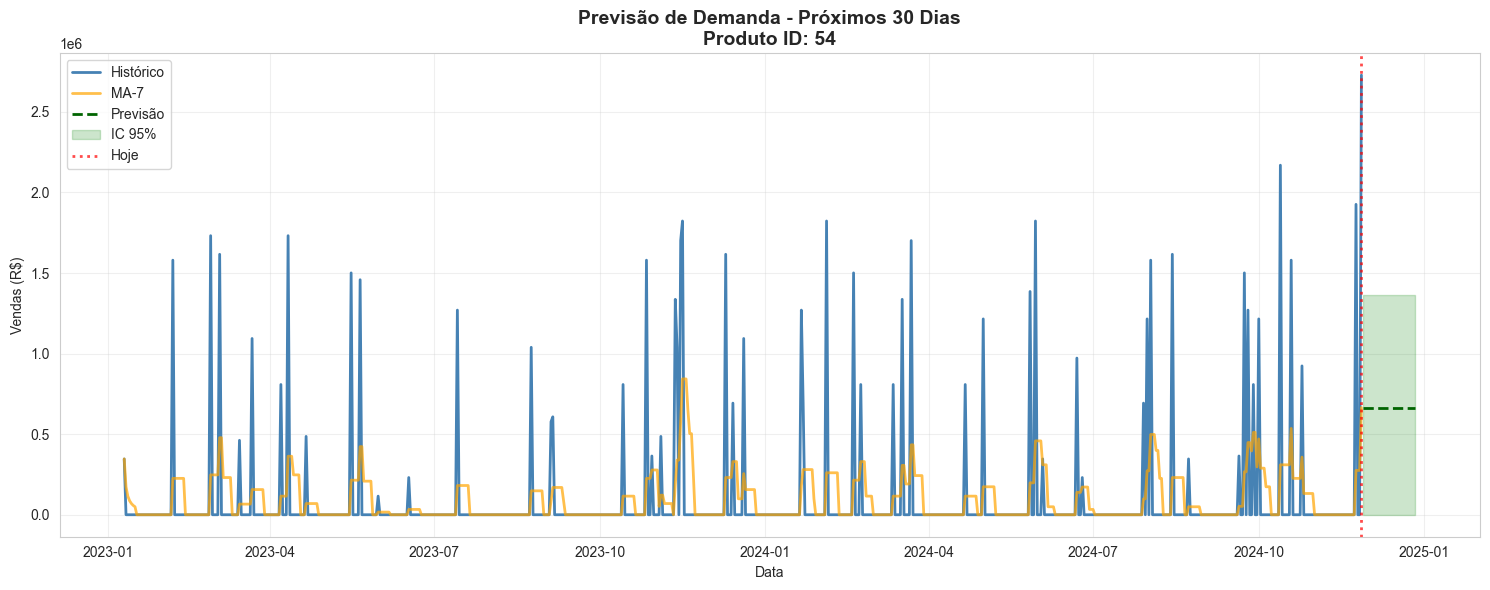


✓ Gráfico de previsões futuras exibido com sucesso


In [10]:
"""
Visualização: Previsões Futuras
===============================
"""

fig, ax = plt.subplots(figsize=(15, 6))

# Histórico
ax.plot(vendas_completo['data'], vendas_completo['vendas'], label='Histórico', color='steelblue', linewidth=2)
ax.plot(vendas_completo['data'], vendas_completo['ma7'], label='MA-7', color='orange', linewidth=2, alpha=0.7)

# Previsões futuras
ax.plot(previsoes_futuras['data'], previsoes_futuras['predicao'], label='Previsão', 
        color='darkgreen', linewidth=2, linestyle='--')
ax.fill_between(previsoes_futuras['data'], 
                 previsoes_futuras['limite_inferior'],
                 previsoes_futuras['limite_superior'],
                 alpha=0.2, color='green', label='IC 95%')

# Linha de separação
ax.axvline(x=ultima_data, color='red', linestyle=':', linewidth=2, alpha=0.7, label='Hoje')

ax.set_title(f'Previsão de Demanda - Próximos 30 Dias\nProduto ID: {id_produto}', fontsize=14, fontweight='bold')
ax.set_ylabel('Vendas (R$)')
ax.set_xlabel('Data')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Gráfico de previsões futuras exibido com sucesso")

---

## CONCLUSÃO DO NOTEBOOK 04

### Seções Completadas

| Questão | Descrição | Status |
|---------|-----------|--------|
| **Q7** | Modelo Baseline de Previsão | Completo |

### Resultados do Modelo
- **MAE**: R$ {:.2f}
- **RMSE**: R$ {:.2f}
- **MAPE**: {:.2f}%
- **R² Score**: {:.4f}
- **Acurácia (erro < 20%)**: {:.1f}%

### Próximo Passo
- **Notebook 05**: Sistema de Recomendação (Q8)

### Arquivos Gerados
- Previsões exportadas: `data/processed/previsoes_produto_X.csv`